<class 'pandas.DataFrame'>
RangeIndex: 14483 entries, 0 to 14482
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Arrival_Date   14483 non-null  datetime64[us]
 1   Vessel_ID      14483 non-null  str           
 2   Vessel_Type    14483 non-null  str           
 3   Cargo_tons     14483 non-null  int64         
 4   Berth_Time_hr  14483 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 565.9 KB
             Arrival_Date Vessel_ID Vessel_Type  Cargo_tons  Berth_Time_hr
0     2022-01-01 03:14:00   V000001   Container       17815           16.5
1     2022-01-01 06:06:00   V000002   Container       17211           24.2
2     2022-01-01 07:27:00   V000003      Tanker       37291           31.6
3     2022-01-01 20:59:00   V000004      Tanker       29932           38.2
4     2022-01-01 12:29:00   V000005      Tanker       39380           40.9
...              

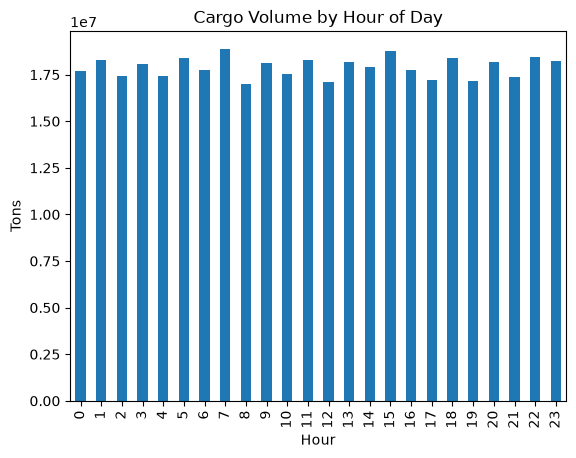

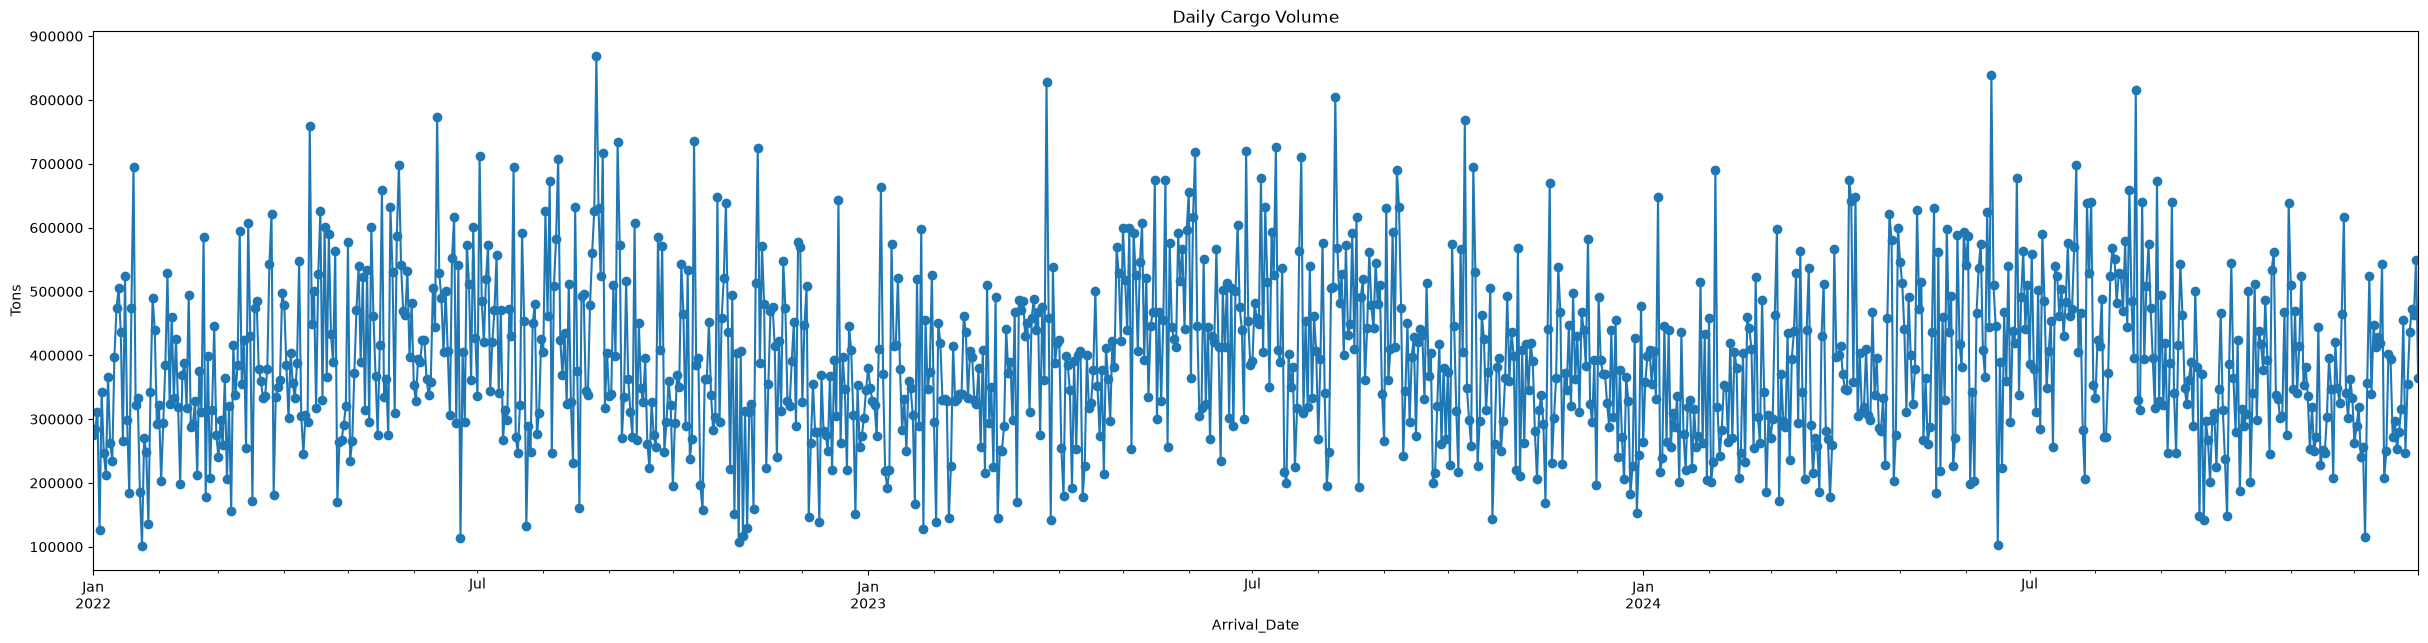

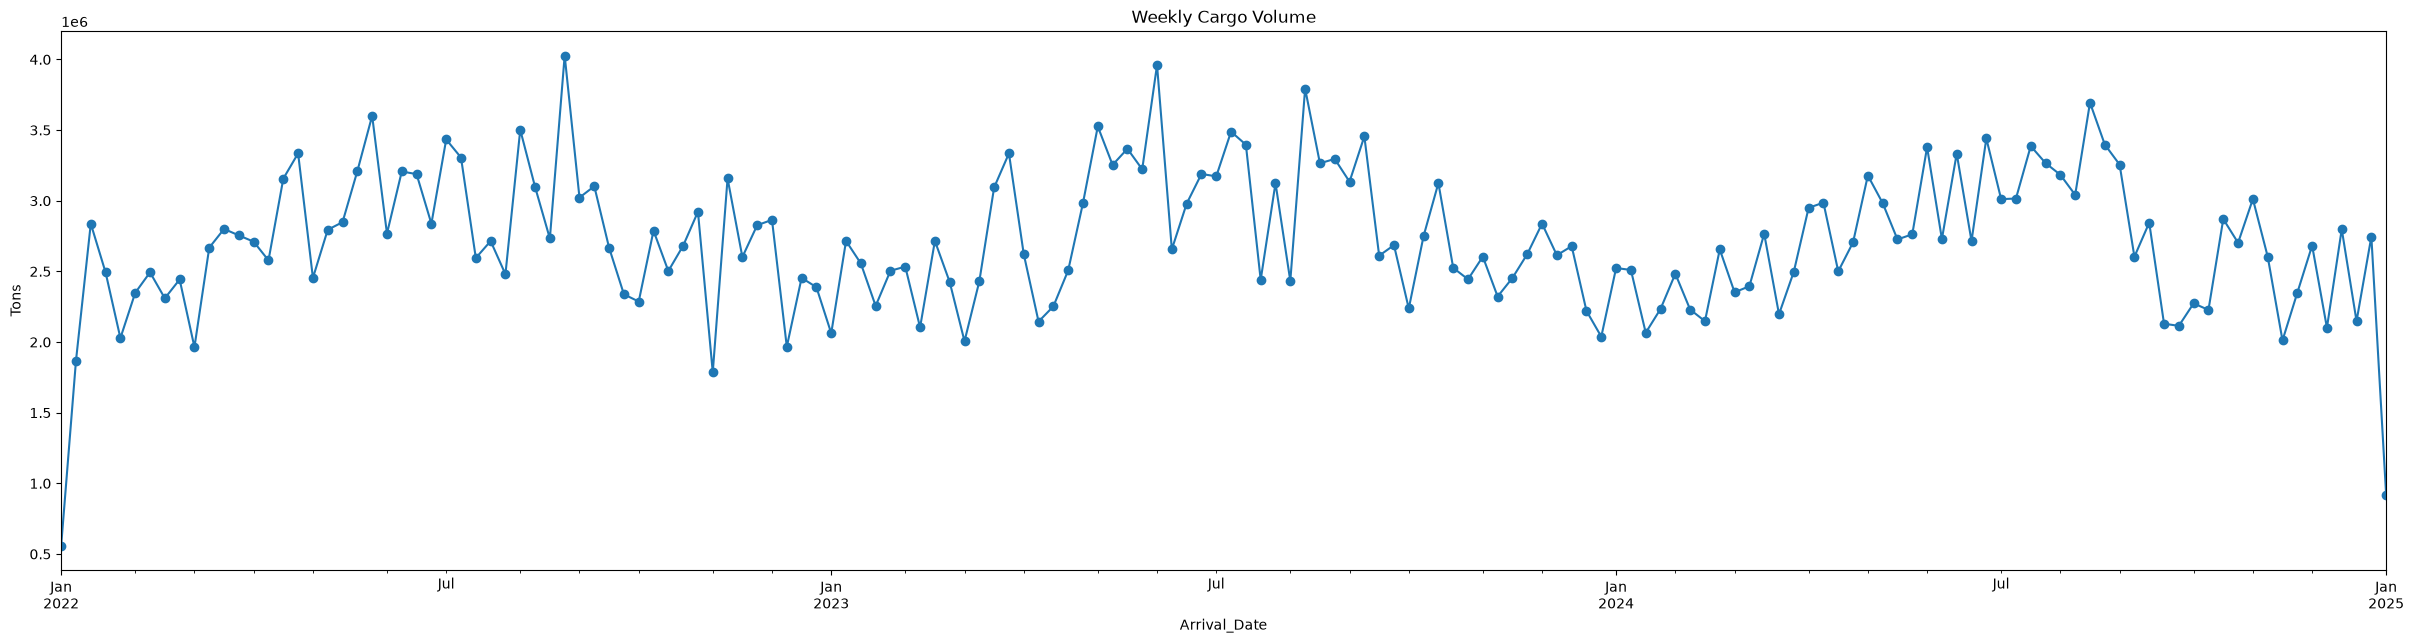

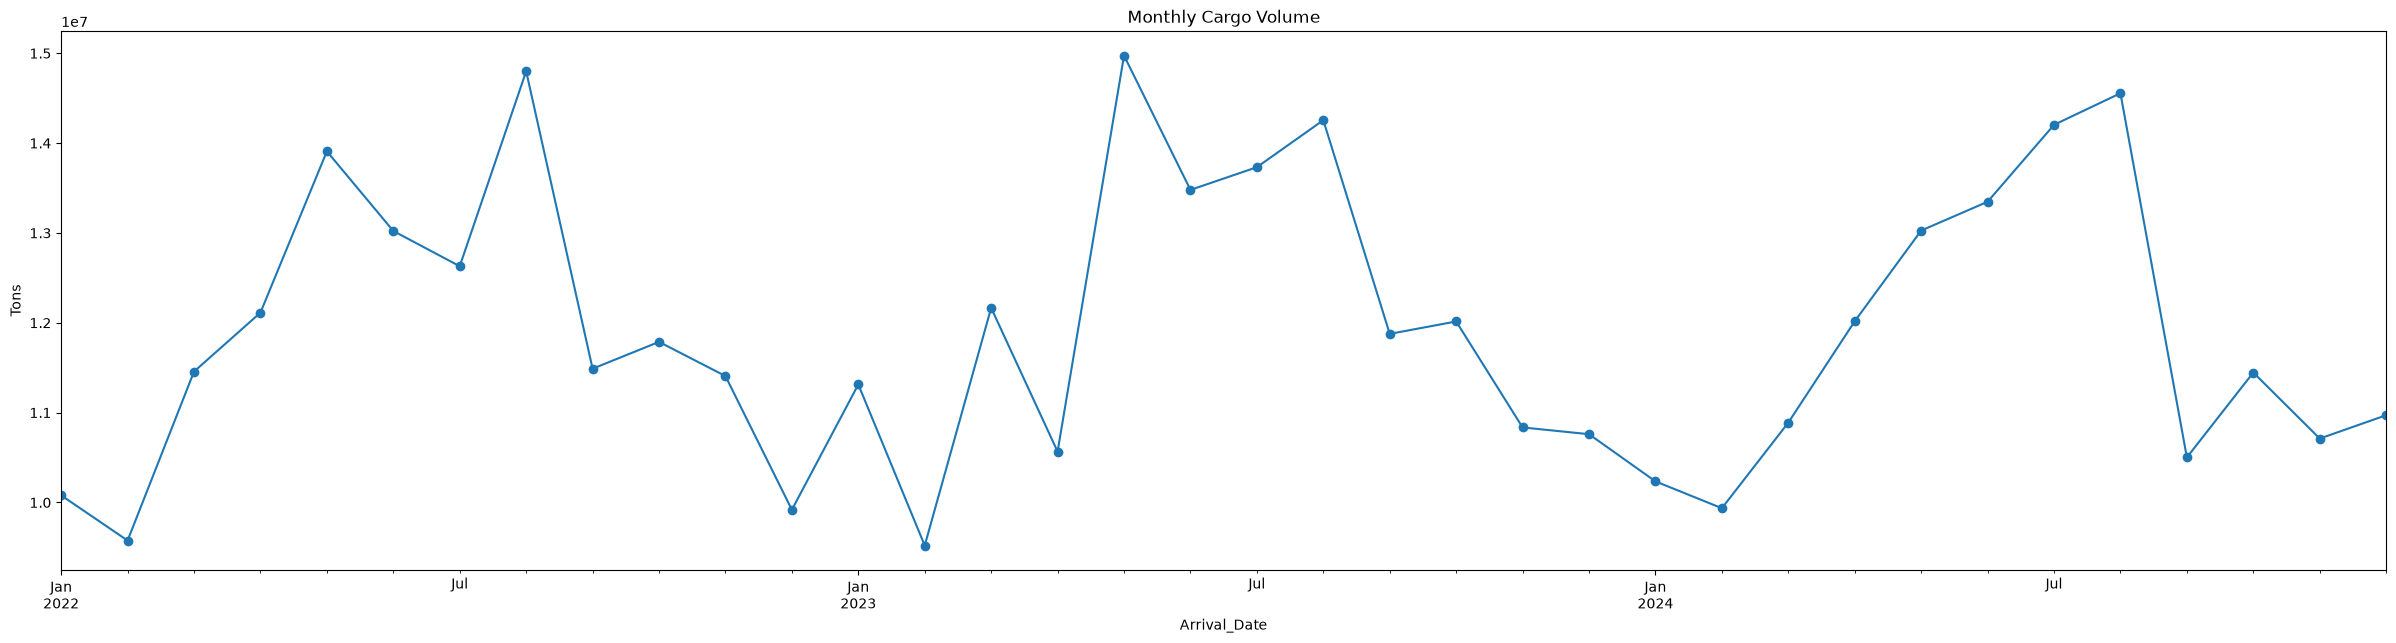

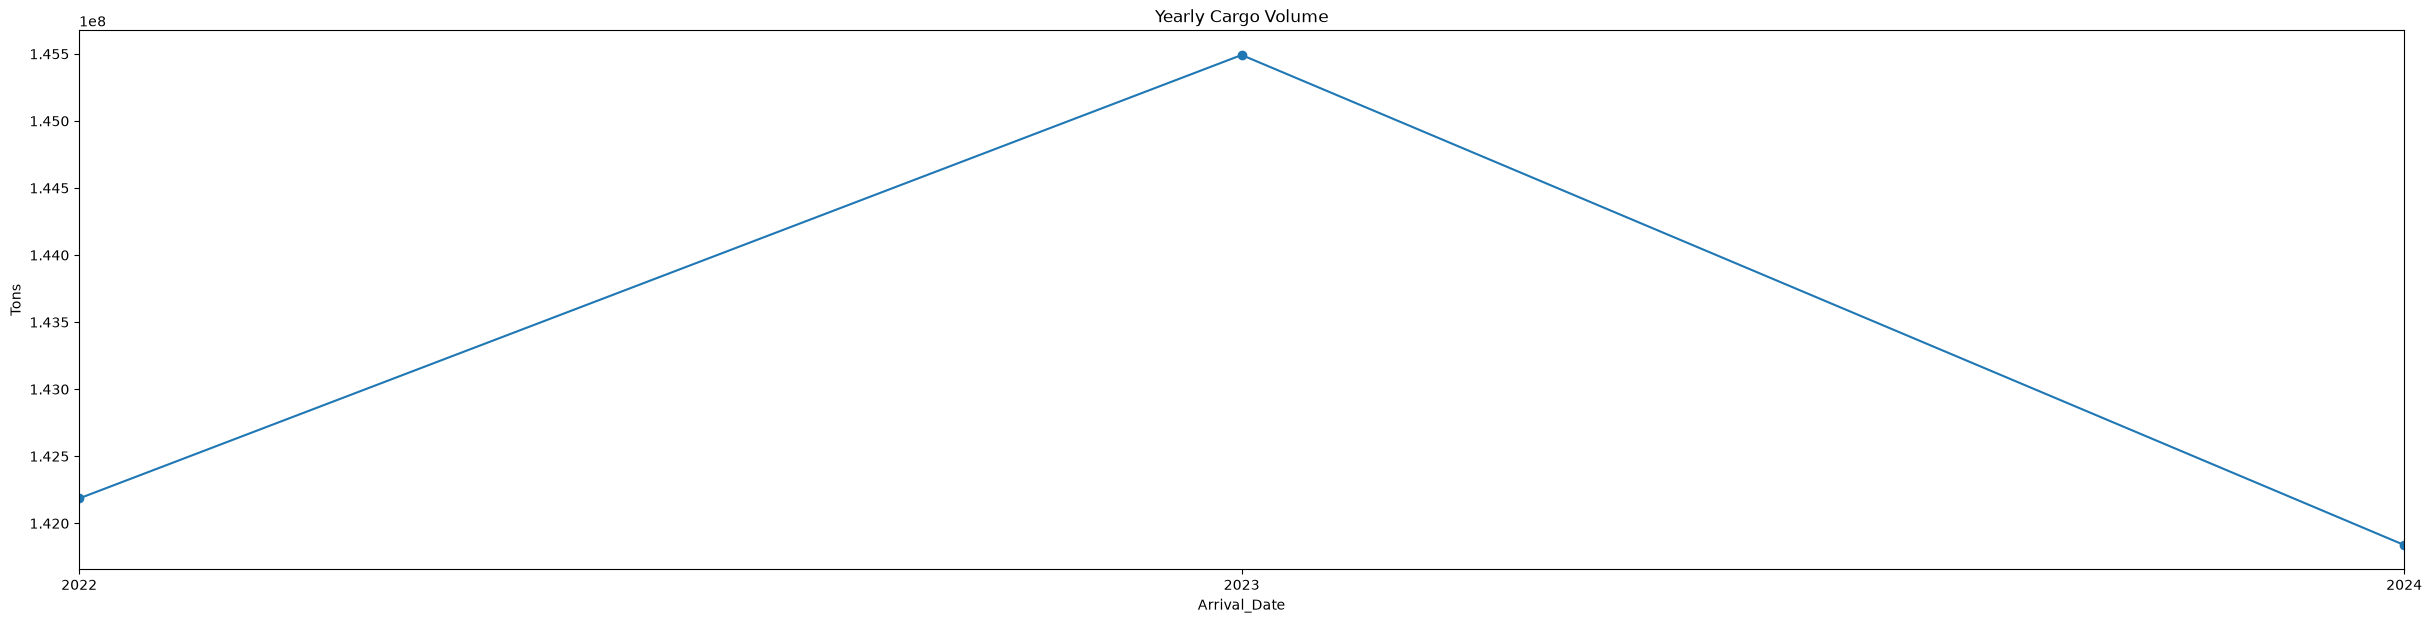

Cargo Statistics by Vessel Type (with overall row)
                     mean           std           var
Bulk         30158.860498  12240.383380  1.498270e+08
Container    16628.958133   6087.424235  3.705673e+07
Tanker       47612.662980  14648.149692  2.145683e+08
All Vessels  29656.528413  16945.350592  2.871449e+08
1.8159876628458316 1.8221203721028079 3.320122650432075


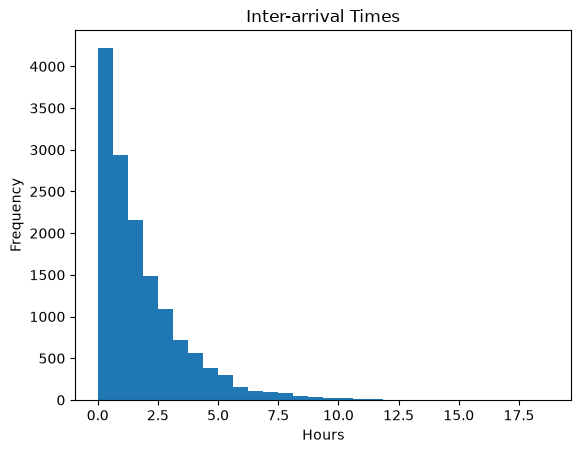

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import scipy as sp
portData = r'.\data\portData.xlsx'
portData = pd.read_excel(portData)
portData.info()
print(portData)

#Hourly
by_hour = portData.groupby(portData["Arrival_Date"].dt.hour)["Cargo_tons"].agg(["sum", "mean", "std", "var"])
print(by_hour)
by_hour["sum"].plot(kind="bar", title="Cargo Volume by Hour of Day", ylabel="Tons", xlabel="Hour")
plt.show()

#Daily
daily = portData.groupby(portData["Arrival_Date"].dt.date)["Cargo_tons"].sum()
daily.index = pd.to_datetime(daily.index)
daily.plot(marker="o", title="Daily Cargo Volume", ylabel="Tons", figsize=(30, 7))
plt.show()
plt.show()

# Weekly
weekly = daily.resample("W").sum()
weekly.plot(marker="o", title="Weekly Cargo Volume", ylabel="Tons", figsize=(30, 7))
plt.show()

# Monthly
monthly = daily.resample("ME").sum()
monthly.plot(marker="o", title="Monthly Cargo Volume", ylabel="Tons", figsize=(30, 7))
plt.show()

# Yearly
yearly = daily.resample("YE").sum()
yearly.plot(marker="o", title="Yearly Cargo Volume", ylabel="Tons", figsize=(30, 7))
plt.show()

#Summary Statistics
summary_by_type = portData.groupby("Vessel_Type")["Cargo_tons"].agg(["mean", "std", "var"])

overall_stats = portData["Cargo_tons"].agg(["mean", "std", "var"])
overall_stats.name = "All Vessels"  # this becomes the row label
summary_by_type = pd.concat([summary_by_type, overall_stats.to_frame().T])

print("Cargo Statistics by Vessel Type (with overall row)")
print(summary_by_type)

portData = portData.sort_values("Arrival_Date")
inter_arrival = portData["Arrival_Date"].diff()
plt.show()

portData = portData.sort_values("Arrival_Date")
inter_arrival = portData["Arrival_Date"].diff().dt.total_seconds() / 3600
print(inter_arrival.mean(), inter_arrival.std(), inter_arrival.var())
inter_arrival.plot(kind="hist", bins=30, title="Inter-arrival Times", xlabel="Hours")
plt.show()

4.3 Distribution Fitting and Understanding Cargo Volume 

Exponential Fitting Lambda Parameter for Containers is:  6.01360585568351e-05
Normal Fitting Parameters mu and sigma2 for Containers are:  16628.958132580163  and  37050577.195788264
Gamma Fitting Parameters alpha and beta for Containers are:  7.463372219921521  and  0.000448817788848657
Lognormal Fitting Parameters mu and sigma2 for Containers are:  9.6560307456141  and  0.12574034947074722
Exponential Fitting Lambda Parameter for Tankers is:  2.1002816003592177e-05
Normal Fitting Parameters mu and sigma2 for Tankers are:  47612.6629795246  and  214517790.8734727
Gamma Fitting Parameters alpha and beta for Tankers are:  10.567728050765254  and  0.00022195204782622245
Lognormal Fitting Parameters mu and sigma2 for Tankers are:  10.725646872434975  and  0.09041432277341903
Exponential Fitting Lambda Parameter for Bulk is:  3.3157751436232134e-05
Normal Fitting Parameters mu and sigma2 for Bulk are:  30158.86049822064  and  149791439.13593662
Gamma Fitting Parameters alpha and beta for B

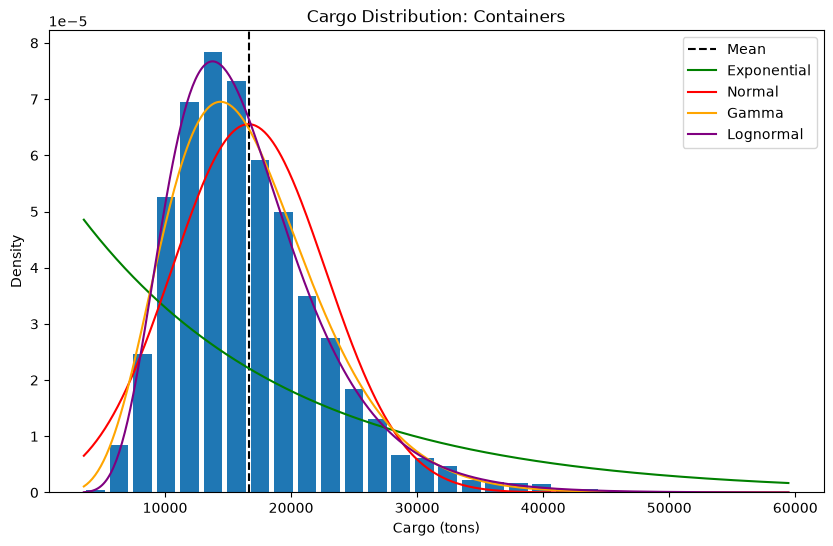

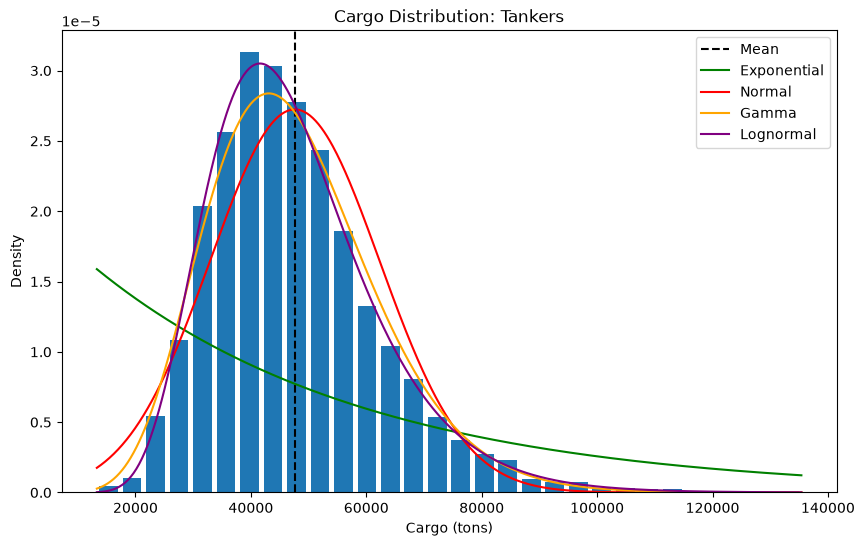

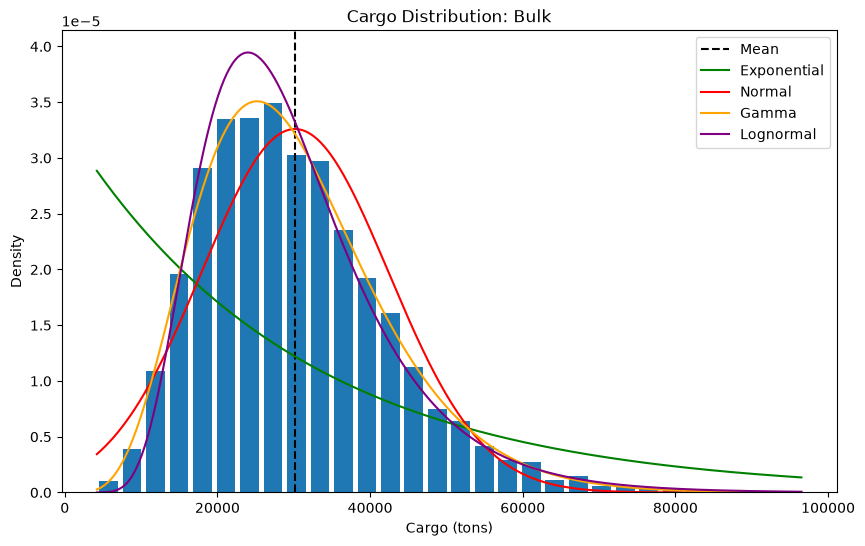

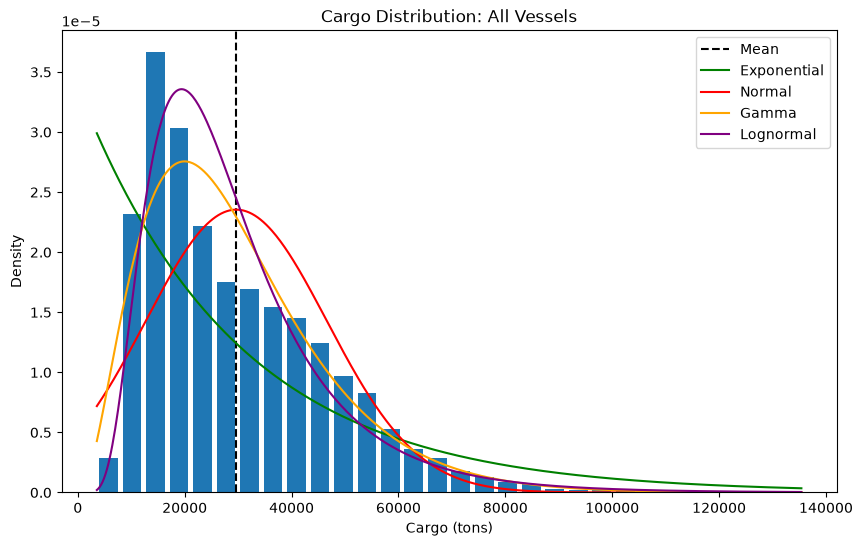

In [32]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt


# Cargo per vessel type and for all vessels
cargoContainer = data.loc[data['Vessel_Type'] == 'Container', 'Cargo_tons']
cargoTanker = data.loc[data['Vessel_Type'] == 'Tanker', 'Cargo_tons']
cargoBulk = data.loc[data['Vessel_Type'] == 'Bulk', 'Cargo_tons']
cargoAll = data['Cargo_tons']


#Container Vessel Type
# Histogram creation
plt.figure(figsize=(10, 6))
plt.hist(cargoContainer, bins=30, rwidth=0.8, density=True)

# Method of moments
M1 = np.mean(cargoContainer)
M2 = np.mean(cargoContainer**2)
plt.axvline(M1, color='black', linestyle='--', label='Mean')

# Exponential distribution fitting
lam = 1/M1
fitExpDistContainer = stats.expon(scale=1/lam)
print('Exponential Fitting Lambda Parameter for Containers is: ', lam)

# Normal distribution fitting
mu = M1
sigma2 = M2 - M1**2
fitNormDistContainer = stats.norm(mu, np.sqrt(sigma2))
print('Normal Fitting Parameters mu and sigma2 for Containers are: ', mu, ' and ', sigma2)

# Gamma distribution fitting
alpha = M1**2 / (M2 - M1**2)
beta = M1 / (M2 - M1**2)
fitGammaDistContainer = stats.gamma(alpha, scale=1/beta)
print('Gamma Fitting Parameters alpha and beta for Containers are: ', alpha, ' and ', beta)

# Lognormal distribution fitting
sigma2_ln = np.log(M2 / M1**2)
mu_ln = np.log(M1) - sigma2_ln / 2
fitLognormDistContainer = stats.lognorm(s=np.sqrt(sigma2_ln), scale=np.exp(mu_ln))
print('Lognormal Fitting Parameters mu and sigma2 for Containers are: ', mu_ln, ' and ', sigma2_ln)

# Graph of fittings and original data for visual analysis
xs = np.linspace(np.min(cargoContainer), np.max(cargoContainer), 500)
plt.plot(xs, fitExpDistContainer.pdf(xs), color='g', label='Exponential')
plt.plot(xs, fitNormDistContainer.pdf(xs), color='red', label='Normal')
plt.plot(xs, fitGammaDistContainer.pdf(xs), color='orange', label='Gamma')
plt.plot(xs, fitLognormDistContainer.pdf(xs), color='purple', label='Lognormal')
plt.title('Cargo Distribution: Containers')
plt.xlabel('Cargo (tons)')
plt.ylabel('Density')
plt.legend()


#Tanker vessel type
# Histogram creation
plt.figure(figsize=(10, 6))
plt.hist(cargoTanker, bins=30, rwidth=0.8, density=True)

# Method of moments
M1 = np.mean(cargoTanker)
M2 = np.mean(cargoTanker**2)
plt.axvline(M1, color='black', linestyle='--', label='Mean')

# Exponential distribution fitting
lam = 1/M1
fitExpDistTanker = stats.expon(scale=1/lam)
print('Exponential Fitting Lambda Parameter for Tankers is: ', lam)

# Normal distribution fitting
mu = M1
sigma2 = M2 - M1**2
fitNormDistTanker = stats.norm(mu, np.sqrt(sigma2))
print('Normal Fitting Parameters mu and sigma2 for Tankers are: ', mu, ' and ', sigma2)

# Gamma distribution fitting
alpha = M1**2 / (M2 - M1**2)
beta = M1 / (M2 - M1**2)
fitGammaDistTanker = stats.gamma(alpha, scale=1/beta)
print('Gamma Fitting Parameters alpha and beta for Tankers are: ', alpha, ' and ', beta)

# Lognormal distribution fitting
sigma2_ln = np.log(M2 / M1**2)
mu_ln = np.log(M1) - sigma2_ln / 2
fitLognormDistTanker = stats.lognorm(s=np.sqrt(sigma2_ln), scale=np.exp(mu_ln))
print('Lognormal Fitting Parameters mu and sigma2 for Tankers are: ', mu_ln, ' and ', sigma2_ln)

# Graph of fittings and original data for visual analysis
xs = np.linspace(np.min(cargoTanker), np.max(cargoTanker), 500)
plt.plot(xs, fitExpDistTanker.pdf(xs), color='g', label='Exponential')
plt.plot(xs, fitNormDistTanker.pdf(xs), color='red', label='Normal')
plt.plot(xs, fitGammaDistTanker.pdf(xs), color='orange', label='Gamma')
plt.plot(xs, fitLognormDistTanker.pdf(xs), color='purple', label='Lognormal')
plt.title('Cargo Distribution: Tankers')
plt.xlabel('Cargo (tons)')
plt.ylabel('Density')
plt.legend()


#Bulk Vessel type
# Histogram creation
plt.figure(figsize=(10, 6))
plt.hist(cargoBulk, bins=30, rwidth=0.8, density=True)

# Method of moments
M1 = np.mean(cargoBulk)
M2 = np.mean(cargoBulk**2)
plt.axvline(M1, color='black', linestyle='--', label='Mean')

# Exponential distribution fitting
lam = 1/M1
fitExpDistBulk = stats.expon(scale=1/lam)
print('Exponential Fitting Lambda Parameter for Bulk is: ', lam)

# Normal distribution fitting
mu = M1
sigma2 = M2 - M1**2
fitNormDistBulk = stats.norm(mu, np.sqrt(sigma2))
print('Normal Fitting Parameters mu and sigma2 for Bulk are: ', mu, ' and ', sigma2)

# Gamma distribution fitting
alpha = M1**2 / (M2 - M1**2)
beta = M1 / (M2 - M1**2)
fitGammaDistBulk = stats.gamma(alpha, scale=1/beta)
print('Gamma Fitting Parameters alpha and beta for Bulk are: ', alpha, ' and ', beta)

# Lognormal distribution fitting
sigma2_ln = np.log(M2 / M1**2)
mu_ln = np.log(M1) - sigma2_ln / 2
fitLognormDistBulk = stats.lognorm(s=np.sqrt(sigma2_ln), scale=np.exp(mu_ln))
print('Lognormal Fitting Parameters mu and sigma2 for Bulk are: ', mu_ln, ' and ', sigma2_ln)

# Graph of fittings and original data for visual analysis
xs = np.linspace(np.min(cargoBulk), np.max(cargoBulk), 500)
plt.plot(xs, fitExpDistBulk.pdf(xs), color='g', label='Exponential')
plt.plot(xs, fitNormDistBulk.pdf(xs), color='red', label='Normal')
plt.plot(xs, fitGammaDistBulk.pdf(xs), color='orange', label='Gamma')
plt.plot(xs, fitLognormDistBulk.pdf(xs), color='purple', label='Lognormal')
plt.title('Cargo Distribution: Bulk')
plt.xlabel('Cargo (tons)')
plt.ylabel('Density')
plt.legend()


#All vessel types
# Histogram creation
plt.figure(figsize=(10, 6))
plt.hist(cargoAll, bins=30, rwidth=0.8, density=True)

# Method of moments
M1 = np.mean(cargoAll)
M2 = np.mean(cargoAll**2)
plt.axvline(M1, color='black', linestyle='--', label='Mean')

# Exponential distribution fitting
lam = 1/M1
fitExpDistAll = stats.expon(scale=1/lam)
print('Exponential Fitting Lambda Parameter for All Vessels is: ', lam)

# Normal distribution fitting
mu = M1
sigma2 = M2 - M1**2
fitNormDistAll = stats.norm(mu, np.sqrt(sigma2))
print('Normal Fitting Parameters mu and sigma2 for All Vessels are: ', mu, ' and ', sigma2)

# Gamma distribution fitting
alpha = M1**2 / (M2 - M1**2)
beta = M1 / (M2 - M1**2)
fitGammaDistAll = stats.gamma(alpha, scale=1/beta)
print('Gamma Fitting Parameters alpha and beta for All Vessels are: ', alpha, ' and ', beta)

# Lognormal distribution fitting
sigma2_ln = np.log(M2 / M1**2)
mu_ln = np.log(M1) - sigma2_ln / 2
fitLognormDistAll = stats.lognorm(s=np.sqrt(sigma2_ln), scale=np.exp(mu_ln))
print('Lognormal Fitting Parameters mu and sigma2 for All Vessels are: ', mu_ln, ' and ', sigma2_ln)

# Graph of fittings and original data for visual analysis
xs = np.linspace(np.min(cargoAll), np.max(cargoAll), 500)
plt.plot(xs, fitExpDistAll.pdf(xs), color='g', label='Exponential')
plt.plot(xs, fitNormDistAll.pdf(xs), color='red', label='Normal')
plt.plot(xs, fitGammaDistAll.pdf(xs), color='orange', label='Gamma')
plt.plot(xs, fitLognormDistAll.pdf(xs), color='purple', label='Lognormal')
plt.title('Cargo Distribution: All Vessels')
plt.xlabel('Cargo (tons)')
plt.ylabel('Density')
plt.legend()

plt.show()


